# Panel cumulative local projections: CPI on decomposed xi x oil (euro sample)

This notebook estimates cumulative panel local projections using quarterly CPI inflation, with `xi` decomposed into `xi_dir`, `xi_amp_1`, and `xi_amp_2` and all three shocks included in the same regression.

This euro notebook restricts the sample to euro-area countries and keeps observations only from each country's euro-adoption quarter onward.

Conventions used here:

- the dependent variable at horizon `h` is the cumulative sum of quarterly CPI inflation from `t` through `t+h`,
- lags of `y` are lags of the underlying quarterly CPI inflation series, not lags of the cumulative target,
- if enabled, annual CPI can replace the cumulative quarterly target only for full calendar-year windows,
- the three decomposed xi-oil shocks enter each horizon regression jointly.


In [57]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp
from io_networks.policy_rates import EURO_ADOPTION_STARTS


In [58]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]
regression_controls = ["output_gap", "exchange_rate", "policy_rate"] 
#regression_controls = ["exchange_rate", "output_gap", "policy_rate"]  

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"output_gap": 3, "exchange_rate": 3, "policy_rate": 3}
include_country_fe = True
include_time_fe = False
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
use_annual_cpi_for_full_year_horizons = False
lag_xi_by_one_year_for_xi_x_oil = True
regression_mode = "components"  # "components", "total_plus_shares", "total_plus_share_amp_1", or "total_plus_share_amp_2"
run_separate_lps = False

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)
print("regression_mode:", regression_mode)
print("run_separate_lps:", run_separate_lps)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'output_gap': 3, 'exchange_rate': 3, 'policy_rate': 3}
include_country_fe: True
include_time_fe: False
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
regression_controls: ['output_gap', 'exchange_rate', 'policy_rate']
use_annual_cpi_for_full_year_horizons: False
lag_xi_by_one_year_for_xi_x_oil: True
regression_mode: components
run_separate_lps: False


In [59]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [60]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

euro_start = (
    pd.Series(EURO_ADOPTION_STARTS, name="euro_start")
    .rename_axis("country")
    .reset_index()
)
euro_start["euro_start"] = pd.PeriodIndex(euro_start["euro_start"], freq="Q")

panel_df = panel_df.copy()
panel_df["period_q"] = pd.PeriodIndex(panel_df["period"].astype(str), freq="Q")

panel_df = (
    panel_df.merge(euro_start, on="country", how="inner")
    .loc[lambda d: d["period_q"] >= d["euro_start"]]
    .drop(columns=["period_q", "euro_start"])
    .sort_values(["country", "time_index"])
    .reset_index(drop=True)
)

xi_component_cols = ["xi_dir", "xi_amp_1", "xi_amp_2"]
missing_xi_component_cols = [col for col in xi_component_cols if col not in panel_df.columns]
if missing_xi_component_cols:
    xi_components = pd.read_parquet(xi_path)[["country", "year", "status", *missing_xi_component_cols]].copy()
    xi_components = xi_components.loc[xi_components["status"] == "ok"].drop(columns="status")
    panel_df = panel_df.merge(xi_components, on=["country", "year"], how="left", validate="many_to_one")
panel_df = panel_df.sort_values(["country", "time_index"]).reset_index(drop=True)

if lag_xi_by_one_year_for_xi_x_oil:
    shift_periods = 4
else:
    shift_periods = 0

panel_df["xi_for_interactions"] = panel_df.groupby("country")["xi"].shift(shift_periods) if shift_periods else panel_df["xi"]

component_shock_cols = ["xi_dir_x_oil", "xi_amp_1_x_oil", "xi_amp_2_x_oil"]
component_source_cols = ["xi_dir", "xi_amp_1", "xi_amp_2"]
component_shock_labels = {
    "xi_dir_x_oil": r"$\xi_{dir} \times \Delta oil$",
    "xi_amp_1_x_oil": r"$\xi_{amp,1} \times \Delta oil$",
    "xi_amp_2_x_oil": r"$\xi_{amp,2} \times \Delta oil$",
}

for source_col, shock_col in zip(component_source_cols, component_shock_cols):
    interaction_source = panel_df.groupby("country")[source_col].shift(shift_periods) if shift_periods else panel_df[source_col]
    panel_df[f"{source_col}_for_interactions"] = interaction_source
    panel_df[shock_col] = interaction_source * panel_df["oil_pct_change"]

denom = panel_df["xi_for_interactions"].replace(0.0, pd.NA)
panel_df["share_amp_1"] = panel_df["xi_amp_1_for_interactions"] / denom
panel_df["share_amp_2"] = panel_df["xi_amp_2_for_interactions"] / denom
panel_df["share_amp_1_x_oil"] = panel_df["share_amp_1"] * panel_df["oil_pct_change"]
panel_df["share_amp_2_x_oil"] = panel_df["share_amp_2"] * panel_df["oil_pct_change"]

if regression_mode == "components":
    shock_cols = component_shock_cols
    shock_labels = component_shock_labels
elif regression_mode == "total_plus_shares":
    shock_cols = ["xi_x_oil", "share_amp_1_x_oil", "share_amp_2_x_oil"]
    shock_labels = {
        "xi_x_oil": r"$\xi \times \Delta oil$",
        "share_amp_1_x_oil": r"$(\xi_{near,m,t-4} / \xi)u_t$",
        "share_amp_2_x_oil": r"$(\xi_{deep,m,t-4} / \xi)u_t$",
    }
elif regression_mode == "total_plus_share_amp_1":
    shock_cols = ["xi_x_oil", "share_amp_1_x_oil"]
    shock_labels = {
        "xi_x_oil": r"$\xi \times \Delta oil$",
        "share_amp_1_x_oil": r"$(\xi_{amp,1} / \xi) \times \Delta oil$",
    }
elif regression_mode == "total_plus_share_amp_2":
    shock_cols = ["xi_x_oil", "share_amp_2_x_oil"]
    shock_labels = {
        "xi_x_oil": r"$\xi \times \Delta oil$",
        "share_amp_2_x_oil": r"$(\xi_{amp,2} / \xi) \times \Delta oil$",
    }
else:
    raise ValueError(f"Unsupported regression_mode: {regression_mode}")

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,1476,19,1999,2022,19.421053,1999-Q1,2022-Q4,77.684211


In [61]:
pairwise_corr = panel_df[shock_cols].corr()
pairwise_corr


,xi_dir_x_oil,xi_amp_1_x_oil,xi_amp_2_x_oil
xi_dir_x_oil,1.000000,0.585739,0.464105
xi_amp_1_x_oil,0.585739,1.000000,0.947065
xi_amp_2_x_oil,0.464105,0.947065,1.000000


In [62]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

panel_df_model[["country", "period", *shock_cols, "cpi_pct_change"]].head()


CPI outlier filter disabled.
Rows kept: 1476


,country,period,xi_dir_x_oil,xi_amp_1_x_oil,xi_amp_2_x_oil,cpi_pct_change
0,AUT,1999-Q1,NaN,NaN,NaN,0.001369
1,AUT,1999-Q2,NaN,NaN,NaN,0.001276
2,AUT,1999-Q3,NaN,NaN,NaN,-0.000091
3,AUT,1999-Q4,NaN,NaN,NaN,0.007191
4,AUT,2000-Q1,0.000333,0.000854,0.001096,0.007320


In [63]:
cum_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
panel_df_model[["country", "period", "cpi_pct_change", *cum_cols]].head(12)


,country,period,cpi_pct_change,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AUT,1999-Q1,0.001369,0.001369,0.002645,0.002554,0.009745,0.017065,0.023614,0.030834,0.037737,0.044587,0.054089,0.056685,0.058951
1,AUT,1999-Q2,0.001276,0.001276,0.001185,0.008376,0.015696,0.022246,0.029465,0.036368,0.043218,0.052720,0.055316,0.057582,0.062750
2,AUT,1999-Q3,-0.000091,-0.000091,0.007100,0.014420,0.020970,0.028190,0.035092,0.041942,0.051444,0.054041,0.056307,0.061475,0.069187
3,AUT,1999-Q4,0.007191,0.007191,0.014511,0.021061,0.028281,0.035183,0.042033,0.051535,0.054132,0.056398,0.061566,0.069278,0.071191
4,AUT,2000-Q1,0.007320,0.007320,0.013870,0.021090,0.027992,0.034842,0.044344,0.046941,0.049207,0.054375,0.062087,0.064000,0.066864
5,AUT,2000-Q2,0.006549,0.006549,0.013769,0.020672,0.027522,0.037024,0.039620,0.041886,0.047054,0.054766,0.056680,0.059544,0.064622
6,AUT,2000-Q3,0.007220,0.007220,0.014123,0.020972,0.030474,0.033071,0.035337,0.040505,0.048217,0.050130,0.052995,0.058072,0.059967
7,AUT,2000-Q4,0.006903,0.006903,0.013752,0.023254,0.025851,0.028117,0.033285,0.040997,0.042910,0.045775,0.050852,0.052747,0.055583
8,AUT,2001-Q1,0.006850,0.006850,0.016352,0.018948,0.021214,0.026382,0.034094,0.036008,0.038872,0.043950,0.045844,0.048681,0.050881
9,AUT,2001-Q2,0.009502,0.009502,0.012099,0.014365,0.019533,0.027245,0.029158,0.032022,0.037100,0.038995,0.041831,0.044031,0.050616


In [64]:
mode_label = {
    "components": "decomposed xi x oil",
    "total_plus_shares": "xi x oil plus amplification shares",
    "total_plus_share_amp_1": "xi x oil plus amplification-share-1",
    "total_plus_share_amp_2": "xi x oil plus amplification-share-2",
}[regression_mode]

if run_separate_lps:
    irf_parts = []
    coef_parts = []
    models = {}
    for shock_col in shock_cols:
        shock_irf_df, shock_coef_df, shock_models = lp.fit_cumulative_panel_local_projections(
            panel_df_model,
            y_col="cpi_pct_change",
            shock_col=shock_col,
            horizons=horizons,
            y_lags=y_lags,
            shock_lags=shock_lags,
            controls=regression_controls,
            control_lags=control_lags,
            include_country_fe=include_country_fe,
            include_time_fe=include_time_fe,
            cov_type=cov_type,
            common_sample=common_sample,
        )
        irf_parts.append(shock_irf_df)
        coef_parts.append(shock_coef_df)
        models[shock_col] = shock_models
    irf_df = pd.concat(irf_parts, ignore_index=True)
    coef_df = pd.concat(coef_parts, ignore_index=True)
    plot_title = f"Cumulative panel local projections (euro sample): CPI response to {mode_label} (separate LPs)"
else:
    irf_df, coef_df, models = lp.fit_cumulative_panel_local_projections_multi(
        panel_df_model,
        y_col="cpi_pct_change",
        shock_cols=shock_cols,
        horizons=horizons,
        y_lags=y_lags,
        shock_lags=shock_lags,
        controls=regression_controls,
        control_lags=control_lags,
        include_country_fe=include_country_fe,
        include_time_fe=include_time_fe,
        cov_type=cov_type,
        common_sample=common_sample,
    )
    plot_title = f"Cumulative panel local projections (euro sample): CPI response to {mode_label} (joint LP)"

irf_df


,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_dir_x_oil,-0.152825,0.137135,-1.114417,0.265100,-0.421605,0.115954,1134.0,19
1,0,xi_amp_1_x_oil,0.993827,0.584401,1.700592,0.089020,-0.151577,2.139231,1134.0,19
2,0,xi_amp_2_x_oil,0.421233,0.384144,1.096550,0.272838,-0.331675,1.174142,1134.0,19
3,1,xi_dir_x_oil,-0.115232,0.191441,-0.601921,0.547227,-0.490450,0.259985,1134.0,19
4,1,xi_amp_1_x_oil,1.187990,1.162810,1.021655,0.306944,-1.091076,3.467056,1134.0,19
5,1,xi_amp_2_x_oil,0.803593,0.805128,0.998094,0.318234,-0.774428,2.381615,1134.0,19
6,2,xi_dir_x_oil,-0.009444,0.247737,-0.038120,0.969592,-0.495000,0.476112,1134.0,19
7,2,xi_amp_1_x_oil,1.188916,1.372971,0.865945,0.386521,-1.502056,3.879889,1134.0,19
8,2,xi_amp_2_x_oil,0.955185,0.920432,1.037757,0.299383,-0.848828,2.759199,1134.0,19
9,3,xi_dir_x_oil,0.101845,0.200837,0.507104,0.612082,-0.291787,0.495477,1134.0,19


In [65]:
from cycler import cycler
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Georgia", "Garamond", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "text.color": "#000000",
    "axes.labelcolor": "#000000",
    "axes.edgecolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "axes.prop_cycle": cycler(color=[
        "#324152",  # main line
        "#c97a3d",
        "#8eb8e5"
    ]),
})

naming = "heterogeneity_euro" if include_time_fe else "baseline_euro"

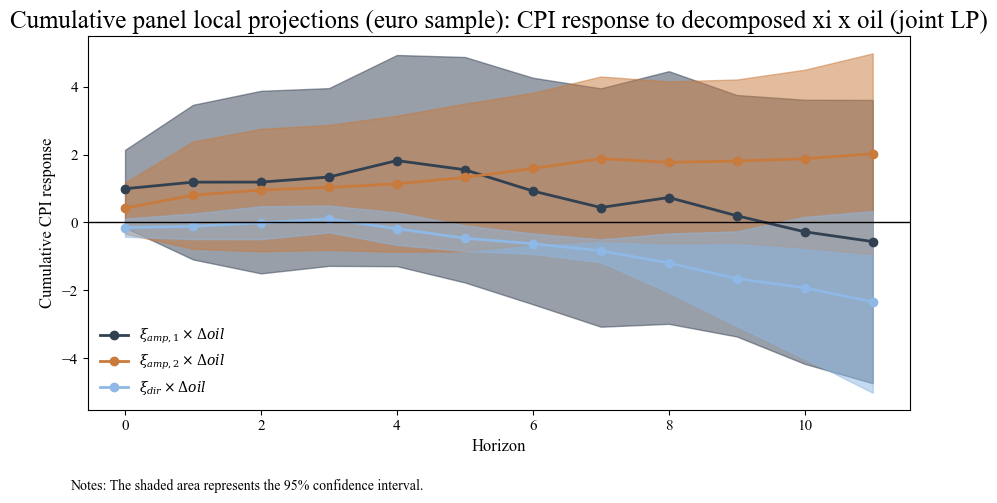

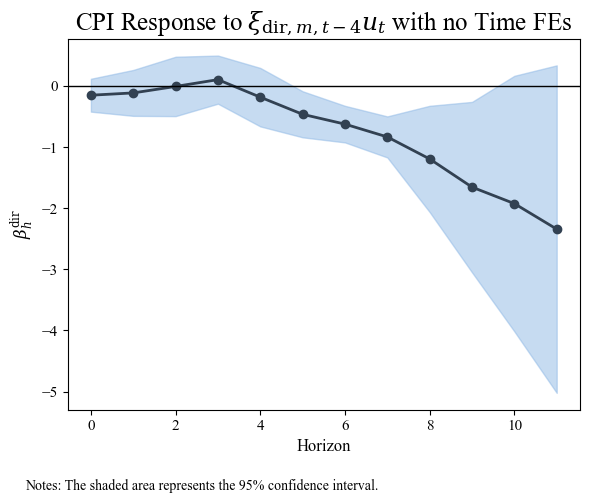

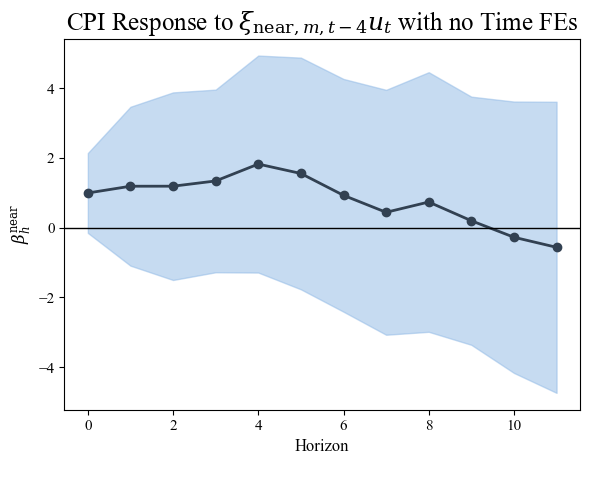

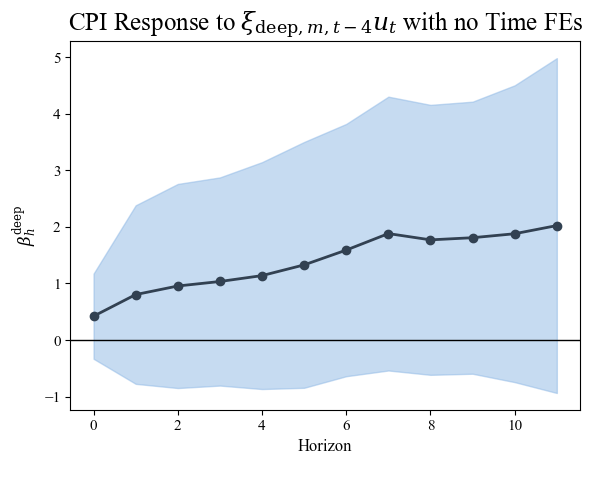

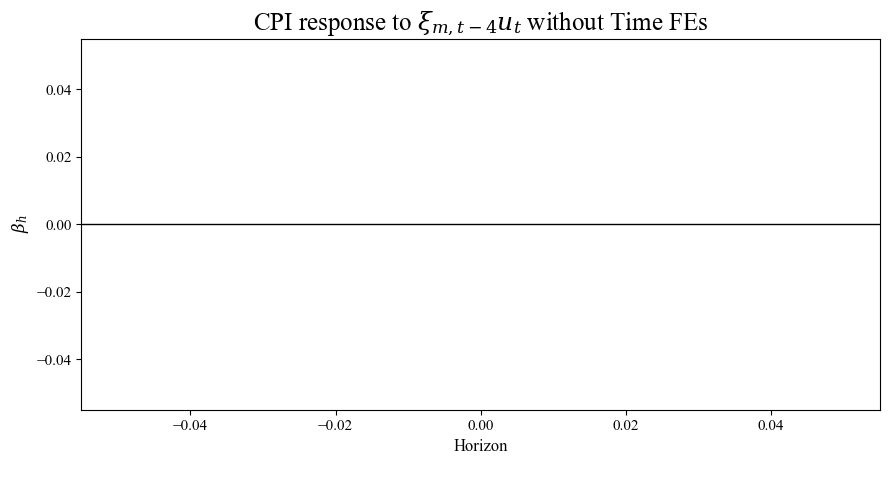

In [66]:
shared_plot_terms = shock_cols
shared_plot_title = plot_title
shared_plot_labels = shock_labels
shared_plot_irf_df = irf_df
shared_line_colors = None
shared_fill_colors = None
shared_fill_alpha = 0.5

if regression_mode == "total_plus_shares":
    shared_plot_terms = ["share_amp_1_x_oil", "share_amp_2_x_oil"]
    shared_plot_labels = {term: shock_labels[term] for term in shared_plot_terms}
    shared_plot_irf_df = irf_df.loc[irf_df["term"].isin(shared_plot_terms)].copy()
    if include_time_fe:
        shared_plot_title = "Euro-sample CPI response to Near and Deep shares with Time FEs"
    else:
        shared_plot_title = "Euro-sample CPI response to Near and Deep shares without Time FEs"
    shared_line_colors = {
        "share_amp_1_x_oil": "#4b637c",
        "share_amp_2_x_oil": "#c97a3d",
    }
    shared_fill_colors = {
        "share_amp_1_x_oil": "#8eb8e5",
        "share_amp_2_x_oil": "#f0ccb0",
    }

shared_default_title = shared_plot_title
component_default_titles = {
    "xi_dir_x_oil": "Euro-sample CPI response to Direction component",
    "xi_amp_1_x_oil": "Euro-sample CPI response to Amplification 1 component",
    "xi_amp_2_x_oil": "Euro-sample CPI response to Amplification 2 component",
}
component_default_titles = {
    term: f"{title} with Time FEs" if include_time_fe else f"{title} without Time FEs"
    for term, title in component_default_titles.items()
}
total_xi_default_title = (
    r"CPI response to $\xi_{m,t-4}u_t$ with Time FEs"
    if include_time_fe
    else r"CPI response to $\xi_{m,t-4}u_t$ without Time FEs"
)

plot_settings = {
    "shared": {
        "title": shared_default_title,
        "xlabel": "Horizon",
        "ylabel": "Cumulative CPI response",
        "figsize": (9, 5),
        "tight_layout_rect": [0, 0.05, 1, 1],
        "figure_text": {
            "x": 0.05,
            "y": 0.01,
            "text": r"Notes: The shaded area represents the 95% confidence interval.",
            "ha": "left",
            "fontsize": 10,
            "color": "black",
            "fontfamily": "serif",
        },
    },
    "components": {
        "xi_dir_x_oil": {
            "title": r"CPI Response to $\xi_{\text{dir}, m,t-4}u_t$ with no Time FEs",
            "xlabel": "Horizon",
            "ylabel": r"$\beta_h^{\text{dir}}$",
            "figsize": (6, 5),
            "tight_layout_rect": [0, 0.05, 1, 1],
            "figure_text": {
                "x": 0.05,
                "y": 0.01,
                "text": r"Notes: The shaded area represents the 95% confidence interval.",
                "ha": "left",
                "fontsize": 10,
                "color": "black",
                "fontfamily": "serif",
            },
        },
        "xi_amp_1_x_oil": {
            "title": r"CPI Response to $\xi_{\text{near}, m,t-4}u_t$ with no Time FEs",
            "xlabel": "Horizon",
            "ylabel": r"$\beta_h^{\text{near}}$",
            "figsize": (6, 5),
            "tight_layout_rect": [0, 0.05, 1, 1],
            "figure_text": {
                "x": 0.05,
                "y": 0.01,
                "text": r" ",
                "ha": "left",
                "fontsize": 10,
                "color": "black",
                "fontfamily": "serif",
            },
        },
        "xi_amp_2_x_oil": {
            "title": r"CPI Response to $\xi_{\text{deep}, m,t-4}u_t$ with no Time FEs",
            "xlabel": "Horizon",
            "ylabel": r"$\beta_h^{\text{deep}}$",
            "figsize": (6, 5),
            "tight_layout_rect": [0, 0.05, 1, 1],
            "figure_text": {
                "x": 0.05,
                "y": 0.01,
                "text": r" ",
                "ha": "left",
                "fontsize": 10,
                "color": "black",
                "fontfamily": "serif",
            },
        },
    },
    "total_xi": {
        "title": total_xi_default_title,
        "xlabel": "Horizon",
        "ylabel": r"$\beta_h$",
        "figsize": (9, 5),
        "tight_layout_rect": [0, 0.05, 1, 1],
        "figure_text": {
            "x": 0.05,
            "y": 0.01,
            "text": " ",
            "ha": "left",
            "fontsize": 10,
            "color": "black",
            "fontfamily": "serif",
        },
    },
}

def add_figure_text(fig, figure_text_settings):
    if not figure_text_settings:
        return
    fig.text(
        figure_text_settings.get("x", 0.05),
        figure_text_settings.get("y", 0.01),
        figure_text_settings.get("text", ""),
        ha=figure_text_settings.get("ha", "left"),
        fontsize=figure_text_settings.get("fontsize", 10),
        color=figure_text_settings.get("color", "black"),
        fontfamily=figure_text_settings.get("fontfamily", "serif"),
    )

def render_multi_irf(irf_subset, term_labels, settings, line_colors=None, fill_colors=None, fill_alpha=0.5):
    fig, ax = plt.subplots(figsize=settings.get("figsize", (9, 5)))
    lp.plot_irf_multi(
        irf_subset,
        title=settings["title"],
        term_labels=term_labels,
        line_colors=line_colors,
        fill_colors=fill_colors,
        fill_alpha=fill_alpha,
        ax=ax,
    )
    ax.set_xlabel(settings.get("xlabel", "Horizon"))
    ax.set_ylabel(settings.get("ylabel", "Cumulative CPI response"))
    add_figure_text(fig, settings.get("figure_text"))
    plt.tight_layout(rect=settings.get("tight_layout_rect", [0, 0.05, 1, 1]))
    plt.show()

def render_single_irf(irf_subset, settings, save_name=None):
    fig, ax = plt.subplots(figsize=settings.get("figsize", (9, 5)))
    lp.plot_irf(
        irf_subset,
        title=settings["title"],
        ax=ax,
    )
    ax.set_xlabel(settings.get("xlabel", "Horizon"))
    ax.set_ylabel(settings.get("ylabel", "Cumulative CPI response"))
    add_figure_text(fig, settings.get("figure_text"))
    fig.tight_layout(rect=settings.get("tight_layout_rect", [0, 0.05, 1, 1]))
    if save_name is not None:
        fig.savefig(f'{save_name}_irf_decomp_{naming}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)

component_file_names = {
    "xi_dir_x_oil": "dir",
    "xi_amp_1_x_oil": "amp1",
    "xi_amp_2_x_oil": "amp2",
}

render_multi_irf(
    shared_plot_irf_df,
    shared_plot_labels,
    plot_settings["shared"],
    line_colors=shared_line_colors,
    fill_colors=shared_fill_colors,
    fill_alpha=shared_fill_alpha,
)

if regression_mode == "components":
    for term in component_shock_cols:
        render_single_irf(
            irf_df.loc[irf_df["term"] == term].copy(),
            plot_settings["components"][term],
            save_name=component_file_names[term],
        )

render_single_irf(
    irf_df.loc[irf_df["term"] == "xi_x_oil"].copy(),
    plot_settings["total_xi"],
)

In [67]:
horizon_to_inspect = 7
shock_to_inspect = shock_cols[0]
if run_separate_lps:
    print(models[shock_to_inspect][horizon_to_inspect].summary())
else:
    print(models[horizon_to_inspect].summary())


                            OLS Regression Results                            
Dep. Variable:          cum_cpi_lead7   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                    -6.580
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               1.00
Time:                        03:48:21   Log-Likelihood:                 2885.3
No. Observations:                1134   AIC:                            -5685.
Df Residuals:                    1091   BIC:                            -5468.
Df Model:                          42                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0249    

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
